### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Image Classification using baseline MobileNet CNN architectures

### Contents
1. Section 1 : Original Data Loading and Splitting
2. Section 2 : Image Resizing and Augmentation for MobileNet
3. Section 3 : Baseline MobileNet Modelling

### System GPU Checks

In [1]:
#Check GPU
!nvidia-smi

Thu May 14 12:59:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   33C    P0             31W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc


/opt/conda/nvvm/libdevice/libdevice.10.bc


### Library Imports

In [3]:
!pip install opencv-python --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
sagemaker-serve 1.9.0 requires onnxruntime, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.4 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.2

In [4]:
!pip install pydot

  Using cached pydot-4.0.1-py3-none-any.whl.metadata (11 kB)
Using cached pydot-4.0.1-py3-none-any.whl (37 kB)


In [5]:
!pip install silence-tensorflow

  Using cached silence_tensorflow-1.2.3-py3-none-any.whl


In [6]:
!pip install numpy

In [7]:
# Importing required libraries and setting global variables
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [8]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [9]:
import pydot
import random
import seaborn as sns
import tensorflow as tf
dataset_path = './25675238/Image_Classification/dataset'
data_files_path = './data_files/Image_Classification'
results_files_path = './results_and_models'

E0000 00:00:1778763645.460764     624 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778763645.472911     624 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778763645.647241     624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778763645.647265     624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778763645.647268     624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778763645.647270     624 computation_placer.cc:177] computation placer already registered. Please check linka

In [10]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth for the first GPU
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Dynamic memory growth enabled successfully.")
    except RuntimeError as e:
        print(f"Error enabling memory growth: {e}")


Dynamic memory growth enabled successfully.


In [11]:
from tensorflow import keras
from datetime import datetime
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers
from keras import optimizers
from keras.models import load_model
from keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_process_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from silence_tensorflow import silence_tensorflow

In [12]:
tf.get_logger().setLevel('ERROR')
silence_tensorflow()

In [13]:
classes = os.listdir(dataset_path)

In [13]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk -F'/' '{printf "%-30s : %s images\n", $NF, $1}'

bernese_mountain_dog           :     218 . images
borzoi                         :     151 . images
brittany_spaniel               :     152 . images
chihuahua                      :     152 . images
german_short-haired_pointer    :     152 . images
norwegian_elkhound             :     196 . images
schipperke                     :     154 . images
sussex_spaniel                 :     151 . images
toy_terrier                    :     172 . images
wire-haired_fox_terrier        :     157 . images


In [14]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 1655

### Section 1 : Original Data Loading and Splitting

In [14]:
# Loading the preprocessed images from npz files
with np.load(data_files_path + '/original_images.npz', allow_pickle=True) as data:
    images = list(data['arr_0'])

In [15]:
# Loading the original labels from the npz files
with np.load(data_files_path + '/original_labels.npz', allow_pickle=True) as data:
    labels = list(data['arr_0'])

In [16]:
# Encoding labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [17]:
# Creating training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, encoded_labels,
    test_size=0.15,
    train_size=0.85,
    random_state=25675238 #Using student ID as random seed
)

In [18]:
# Creating validation set
images_valid = images_train[:250]
labels_valid = labels_train[:250]

images_train = images_train[250:]
labels_train = labels_train[250:]

*The dataset is initially split into 85% training set and 15% testing set.*

*The training set is split into another 70% and 15% validation set*

### Section 2 : Images resizing and Augmentation for MobileNet

In [19]:
# Image resizing
# The images of variable length are resized to 224x224 to standardize the input to the baseline models
resize_train_image = []
resize_valid_image = []
resize_test_image = []

for img in images_train:
    rsz_img = cv2.resize(img, (224, 224))
    resize_train_image.append(rsz_img)
for img in images_valid:
    rsz_img = cv2.resize(img, (224, 224))
    resize_valid_image.append(rsz_img)
for img in images_test:
    rsz_img = cv2.resize(img, (224, 224))
    resize_test_image.append(rsz_img)

In [20]:
# Converting list of images to numpy array for model training
images_train = np.asarray(resize_train_image).astype('float32')
images_valid = np.asarray(resize_valid_image).astype('float32')
images_test = np.asarray(resize_test_image).astype('float32')

In [21]:
labels_train = np.asarray(labels_train)
labels_valid = np.asarray(labels_valid)
labels_test = np.asarray(labels_test)

In [22]:
classes = os.listdir(dataset_path)
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [23]:
# Creating augmentation samples for visualization
augmented_samples_path = './augmented_samples'

datagen = ImageDataGenerator(
    preprocessing_function=mobile_process_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for name in classes:
    i = 0
    for batch in datagen.flow(
        images_train,
        labels_train,
        batch_size=1,
        save_to_dir=augmented_samples_path, 
        save_prefix=f'aug_{name}', 
        save_format='jpeg'
    ):
        i += 1
        if i >= 2:
            break 
    print(f"Created 2 samples for {name}")

# Cleanup augmented samples
!rm -r ./augmented_samples/.ipynb_checkpoints

Created 2 samples for borzoi
Created 2 samples for toy_terrier
Created 2 samples for wire-haired_fox_terrier
Created 2 samples for schipperke
Created 2 samples for chihuahua
Created 2 samples for sussex_spaniel
Created 2 samples for bernese_mountain_dog
Created 2 samples for norwegian_elkhound
Created 2 samples for german_short-haired_pointer
Created 2 samples for brittany_spaniel


rm: cannot remove './augmented_samples/.ipynb_checkpoints': No such file or directory


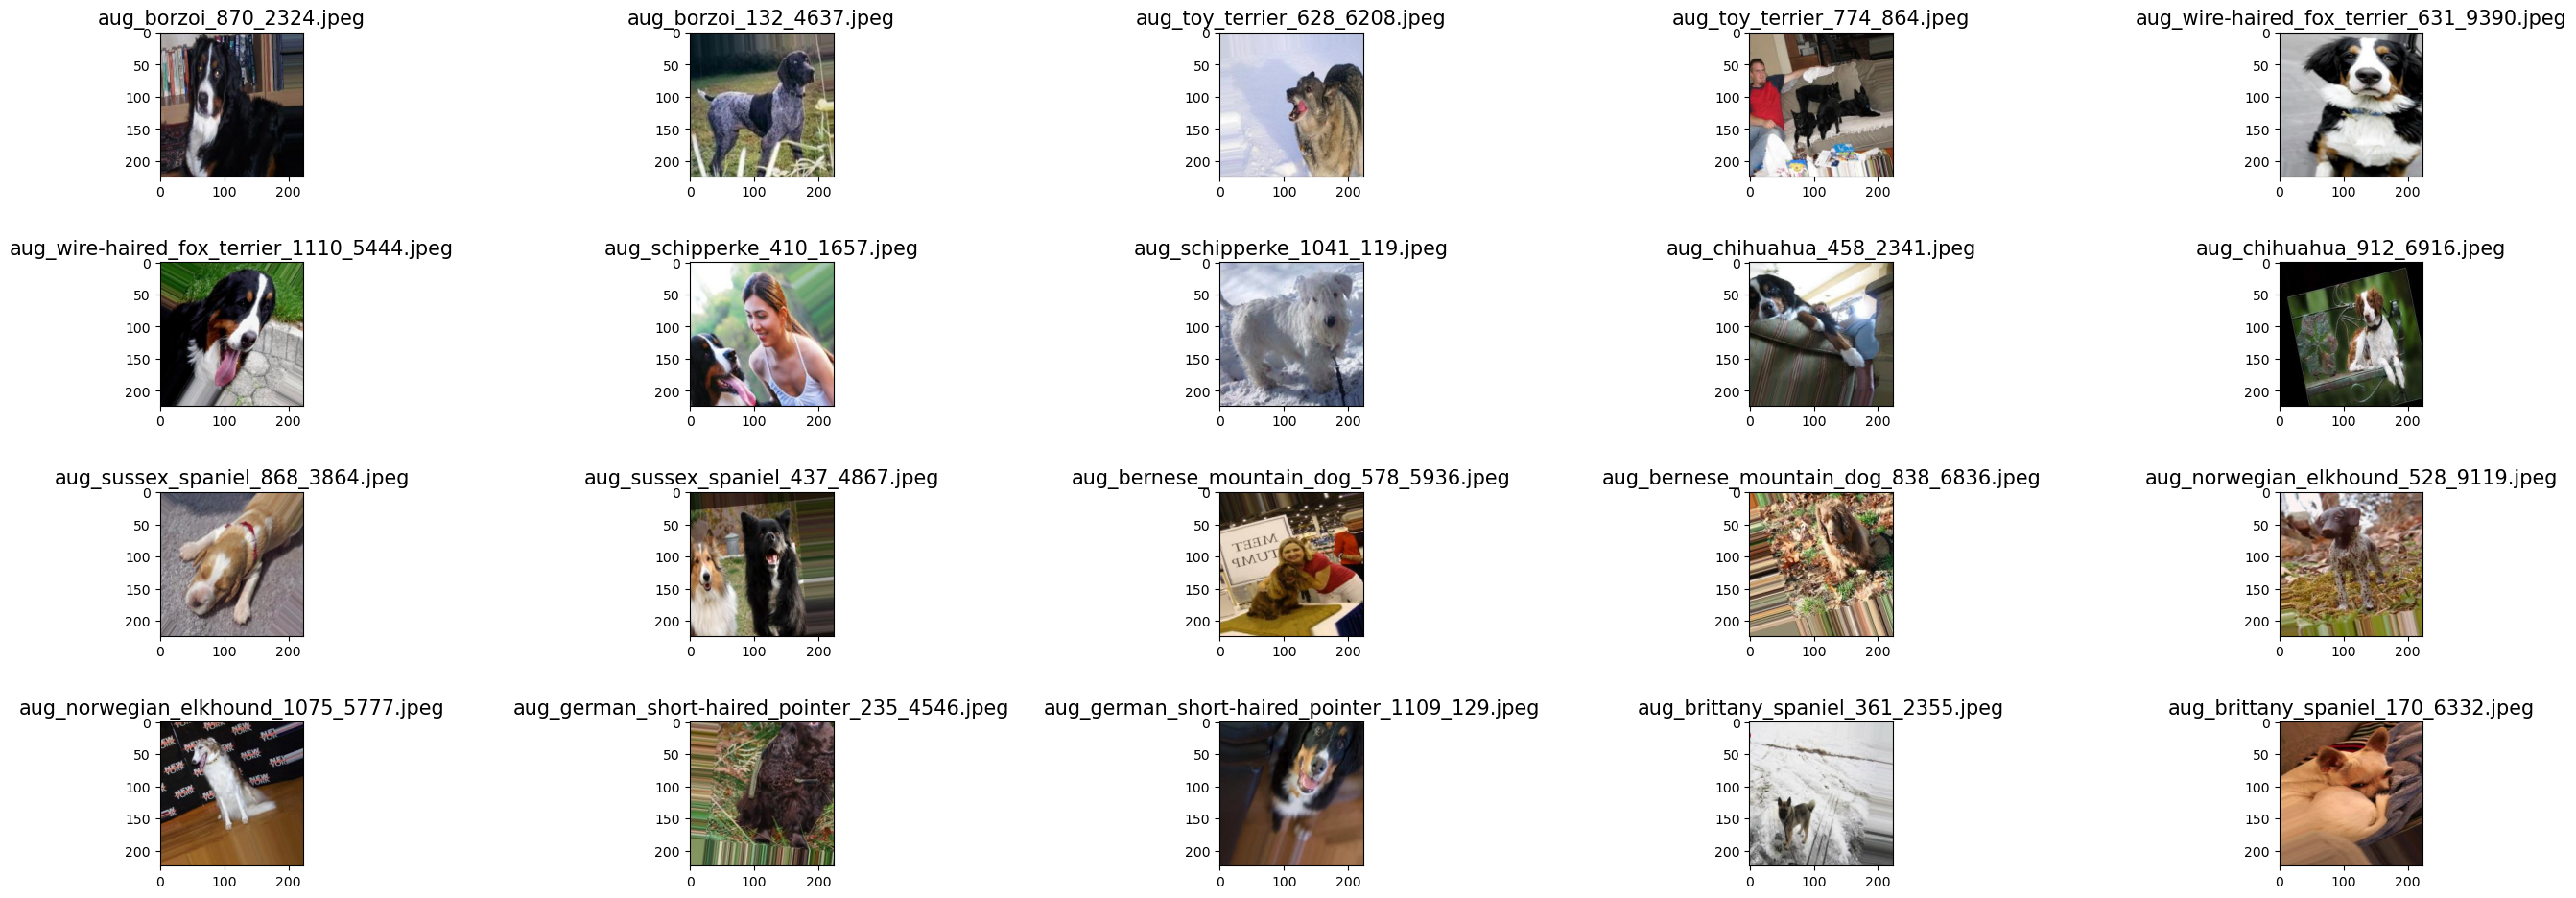

In [24]:
# Analysing augmented images from every class

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(30,10))
augmented_images = os.listdir(augmented_samples_path)
aug_img_idx = 0
for i in range(4):
    for j in range(5):
        img = cv2.imread(augmented_samples_path + "/" + augmented_images[aug_img_idx])
        axes[i,j].imshow(img)
        axes[i,j].set_title(augmented_images[aug_img_idx], fontsize=15)
        aug_img_idx += 1
plt.tight_layout(pad=3.0)
plt.show()

In [25]:
# Cleanup augmented samples
!rm -rf ./augmented_samples/*

In [48]:
train_datagen = ImageDataGenerator(
    preprocessing_function=mobile_process_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=mobile_process_input)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow(
    images_train,
    labels_train,
    batch_size=32,
    seed=25675238
)

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow(
    images_valid,
    labels_valid,
    batch_size=32
)

### Section 3 : Baseline CNN Modelling (MobileNetV2)

In [95]:
# Using MobileNetV2 model with pretrained weights
conv_base_mbn = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_mbn = models.Sequential()
model_mbn.add(conv_base_mbn)
model_mbn.add(layers.GlobalAveragePooling2D())
model_mbn.add(layers.Dense(10, activation='softmax'))

In [96]:
# Freezing the convolutional base of the MobileNetV2 model
for layer in conv_base_mbn.layers:
    layer.trainable = False

In [97]:
model_mbn.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### MobileNetV2 Fit

In [98]:
filepath = './results_and_models/baseline_mobile_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

In [99]:
# CSV logger for adding results to a .csv file
csv_logger = CSVLogger('./results_and_models/baseline_mobile_logs.csv', append=False, separator=',')

In [100]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   
    patience=10,
    verbose=1,                
    restore_best_weights=True
)

In [101]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.2 ,   # Drop LR by 80%
    patience=5,   # Wait 3 epochs before dropping
    min_lr=1e-7,
    verbose=1
)

In [102]:
# Train the model
history = model_mbn.fit(
    train_generator,
    epochs=100,
    steps_per_epoch=31,
    validation_data=validation_generator,
    validation_steps=7,
    callbacks = [checkpoint, csv_logger, reduce_lr, early_stop],
    verbose=0
    )


Epoch 1: val_accuracy improved from None to 0.09375, saving model to ./results_and_models/baseline_mobile_weights/weights_modified.01-2.86.keras



Epoch 1: finished saving model to ./results_and_models/baseline_mobile_weights/weights_modified.01-2.86.keras


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.09375 to 0.10714, saving model to ./results_and_models/baseline_mobile_weights/weights_modified.02-2.80.keras



Epoch 2: finished saving model to ./results_and_models/baseline_mobile_weights/weights_modified.02-2.80.keras


...


Epoch 98: val_accuracy improved from 0.79018 to 0.80357, saving model to ./results_and_models/baseline_mobile_weights/weights_modified.98-1.05.keras



Epoch 98: finished saving model to ./results_and_models/baseline_mobile_weights/weights_modified.98-1.05.keras



Epoch 99: val_accuracy did not improve from 0.80357



Epoch 100: val_accuracy did not improve from 0.80357


Restoring model weights from the end of the best epoch: 98.


In [103]:
model_save_path = results_files_path + '/baseline_mobilenet_models/'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = model_save_path + f"mobilenet_model_{timestamp}.keras"
model_mbn.save(model_name)

#### MobileNet Results

In [104]:
# Retrieving the latest model
saved_models = os.listdir(model_save_path)
saved_models.sort(reverse=True)
latest_model_path = model_save_path + saved_models[0]
print("Loading latest model = ", latest_model_path)
model = load_model(latest_model_path)

Loading latest model =  ./results_and_models/baseline_mobilenet_models/mobilenet_model_20260514_134834.keras


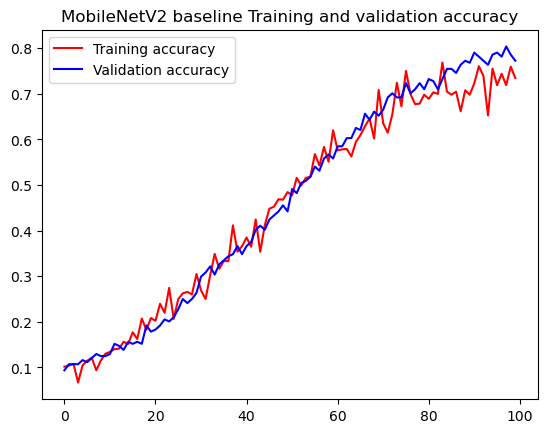

<Figure size 640x480 with 0 Axes>

In [105]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('MobileNetV2 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/MobileNetV2_Baseline_Accuracy.png')

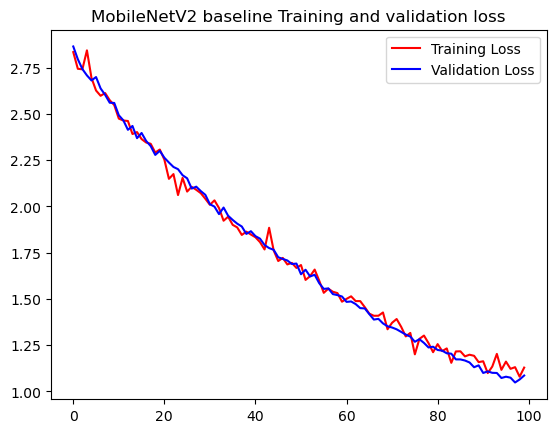

In [106]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('MobileNetV2 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/MobileNetV2_Baseline_Loss.png')

#### MobileNet Model Predictions

In [107]:
model_mbn_predictions = model.predict(images_test)

1/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 515ms/step


In [108]:
lables_mbn_predict = np.argmax(model_mbn_predictions, axis=1)

In [109]:
# Reversing the encoding
labels_test_names = encoder.inverse_transform(labels_test)
labels_mbn_pred_names = encoder.inverse_transform(lables_mbn_predict)

In [110]:
# Calculate Accuracy
accuracy = accuracy_score(labels_test_names, labels_mbn_pred_names)
print(f"Accuracy: {accuracy:.4f}")

# Detailed breakdown
print(classification_report(labels_test_names, labels_mbn_pred_names))

Accuracy: 0.0884
                             precision    recall  f1-score   support

       bernese_mountain_dog       0.00      0.00      0.00        30
                     borzoi       0.50      0.04      0.08        24
           brittany_spaniel       0.09      0.55      0.16        22
                  chihuahua       0.00      0.00      0.00        18
german_short-haired_pointer       0.08      0.16      0.11        25
         norwegian_elkhound       0.12      0.11      0.11        37
                 schipperke       0.00      0.00      0.00        19
             sussex_spaniel       0.03      0.05      0.04        20
                toy_terrier       0.00      0.00      0.00        31
    wire-haired_fox_terrier       0.00      0.00      0.00        23

                   accuracy                           0.09       249
                  macro avg       0.08      0.09      0.05       249
               weighted avg       0.08      0.09      0.05       249



/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


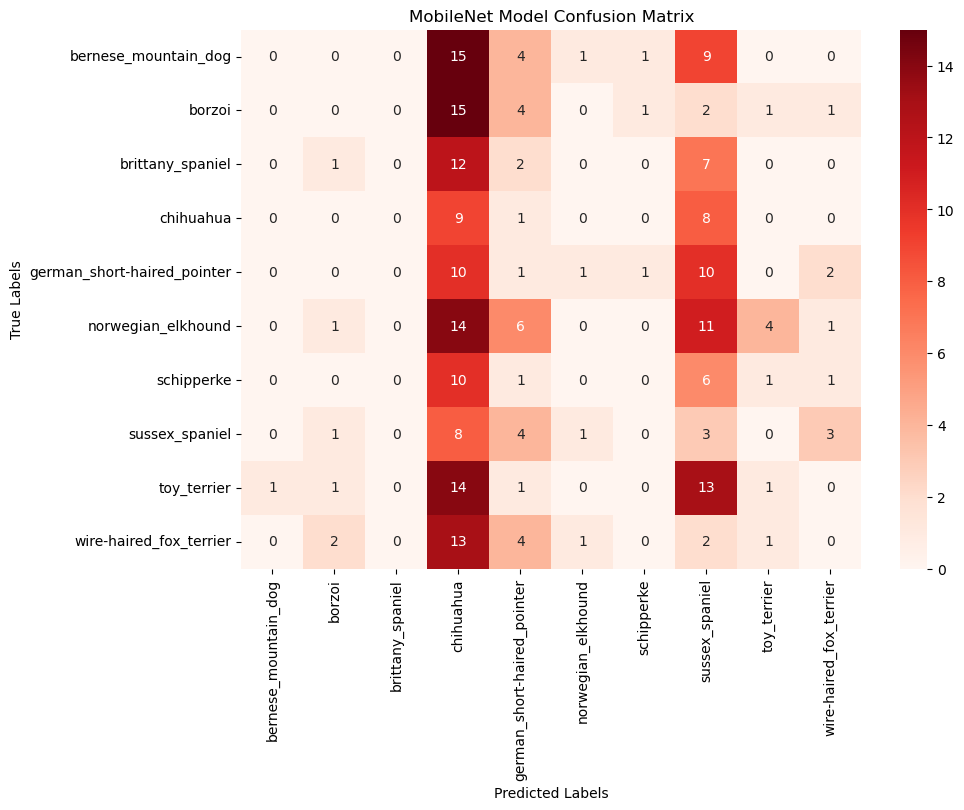

In [94]:
# Plotting confusion matrix
cm = confusion_matrix(labels_test, lables_mbn_predict)

# Plot using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('MobileNet Model Confusion Matrix')
plt.show()